## Spektralanalyse mit NumPy FFT

Vorhergehendes Notebook: [Sinus und Cosinus](02_sin_cos.ipynb)
Nächstes Notebook: [Spektralanalyse mit Rauschen](04_Signal_mit_Rauschen.ipynb)

### Zweiseitige Spektralfunktion mit np.fft

Für die Berechnung eines **Spektrums** aus Abtastwerten verwenden wir die **Fast Fourier Transform (FFT)** aus NumPy: `np.fft.fft(y)` liefert die diskrete Fourier-Transformierte des Signals *y*. Die FFT ist für komplexe und reelle Signale definiert und gibt die Koeffizienten für Frequenzen von 0 bis zur Nyquist-Frequenz und (implizit) für negative Frequenzen aus.

Um das Spektrum **zweiseitig** darzustellen (inkl. negativer Frequenzen von $-f_s/2$ bis $+f_s/2$), werden beide Hilfsfunktionen verwendet:

- **`np.fft.fftfreq(N, d=1/fs)`** – liefert die zu den FFT-Koeffizienten gehörenden Frequenzen (in Hz). Ohne Umsortierung: zuerst 0 … positive Frequenzen, dann negative.
- **`np.fft.fftshift(...)`** – sortiert FFT-Ergebnis und Frequenzachse so um, dass die Anordnung von $-f_s/2$ bis $+f_s/2$ entsteht.

Vorgehen: `Y = np.fft.fft(y)`, dann `freq = np.fft.fftfreq(N, d=1/fs)` und `freq_shifted = np.fft.fftshift(freq)`, `Y_shifted = np.fft.fftshift(Y)`. Der Betrag des Spektrums ist `np.abs(Y_shifted)`; für eine amplitudenrichtige Darstellung kann durch *N* geteilt werden.

### Teil 1: Reelles Cosinus-Signal $A\,\cos(\omega t + \phi)$

Parameter: Amplitude *A*, Frequenz *f* (Hz), Phase *φ* in Grad. Abtastrate 1 kHz, 1024 Punkte.

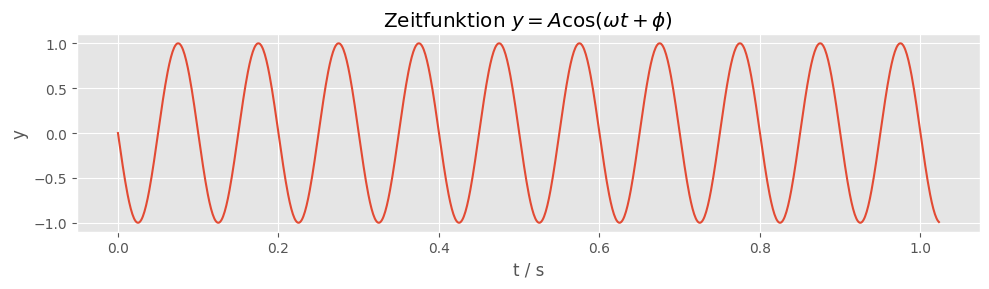

In [32]:
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')

fs = 1000.0   # Abtastrate in Hz
N = 1024     # Anzahl Punkte
A = 1.0      # Amplitude
f = 10   # Frequenz in Hz
phi_deg = 90 # Phase in Grad

phi_rad = np.deg2rad(phi_deg)
t = np.arange(N) / fs
omega = 2 * np.pi * f
y = A * np.cos(omega * t + phi_rad)

plt.figure(figsize=(10, 3))
plt.plot(t, y)
plt.xlabel('t / s')
plt.ylabel('y')
plt.title(r'Zeitfunktion $y = A \cos(\omega t + \phi)$')
plt.grid(True)
plt.tight_layout()
plt.show()

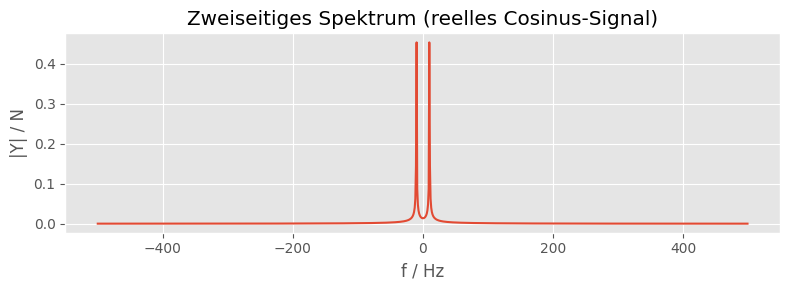

In [33]:
# Zweiseitiges Spektrum
Y = np.fft.fft(y)
freq = np.fft.fftfreq(N, d=1/fs)
freq_shifted = np.fft.fftshift(freq)
Y_shifted = np.fft.fftshift(Y)
magnitude = np.abs(Y_shifted) / N  # amplitudenrichtig (zweiseitig)

plt.figure(figsize=(8, 3))
plt.plot(freq_shifted, magnitude)
plt.xlabel('f / Hz')
plt.ylabel('|Y| / N')
plt.title('Zweiseitiges Spektrum (reelles Cosinus-Signal)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Teil 2: Komplexes Signal (Cosinus + j·Sinus)

Wir bilden das komplexe Signal $z(t) = A\,e^{j(\omega t + \phi)} = A\bigl(\cos(\omega t + \phi) + j\,\sin(\omega t + \phi)\bigr)$ mit denselben Parametern und berechnen wieder Zeitfunktion und zweiseitiges Spektrum.

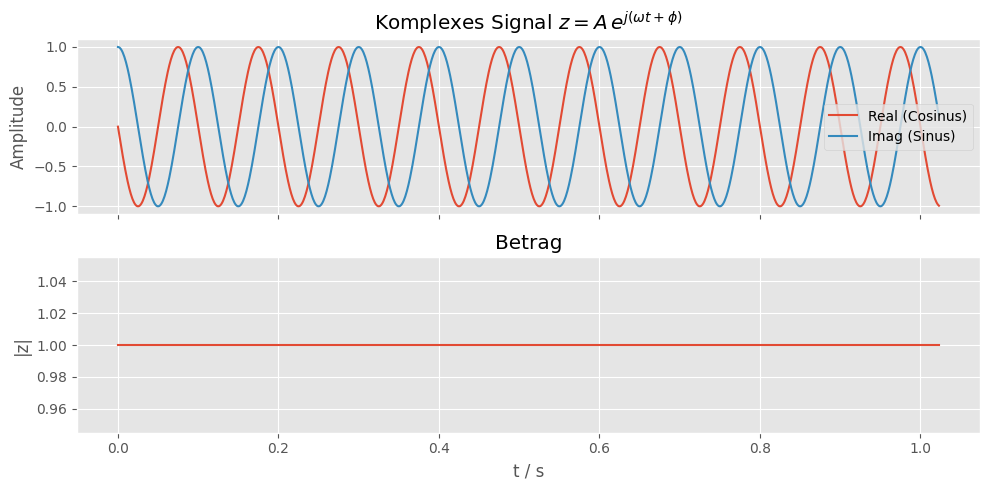

In [34]:
# Komplexes Signal: z = A * exp(j*(omega*t + phi))
z = A * np.exp(1j * (omega * t + phi_rad))

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, np.real(z), label='Real (Cosinus)')
axes[0].plot(t, np.imag(z), label='Imag (Sinus)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(r'Komplexes Signal $z = A\,e^{j(\omega t + \phi)}$')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(t, np.abs(z))
axes[1].set_xlabel('t / s')
axes[1].set_ylabel('|z|')
axes[1].set_title('Betrag')
axes[1].grid(True)
plt.tight_layout()
plt.show()

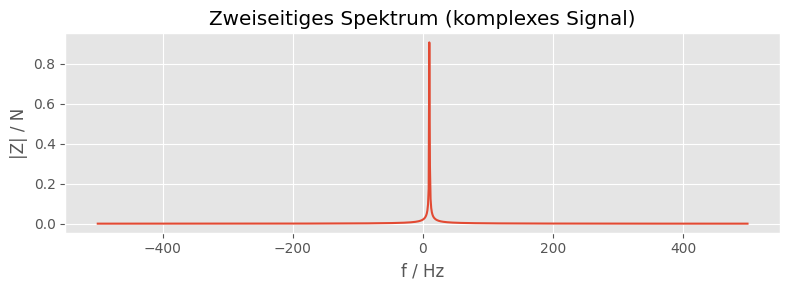

In [35]:
# Zweiseitiges Spektrum des komplexen Signals
Z = np.fft.fft(z)
freq_z = np.fft.fftfreq(N, d=1/fs)
freq_z_shifted = np.fft.fftshift(freq_z)
Z_shifted = np.fft.fftshift(Z)
magnitude_z = np.abs(Z_shifted) / N

plt.figure(figsize=(8, 3))
plt.plot(freq_z_shifted, magnitude_z)
plt.xlabel('f / Hz')
plt.ylabel('|Z| / N')
plt.title('Zweiseitiges Spektrum (komplexes Signal)')
plt.grid(True)
plt.tight_layout()
plt.show()

---

### Schlussfolgerung – Aufgabe für Studierende

**Frage:** Welchen Einfluss hat eine **negative Frequenz** auf Zeitfunktionen und Spektren? Begründe deine Antwort.

ändere dazu in der ersten Zelle den Wert für die Frequenz auf einen negativen Wert und kommentiere das Ergebnis unten, was hat sich verändert, was nicht?:
 
fs = 1000.0   # Abtastrate in Hz  
N = 1024     # Anzahl Punkte  
A = 1.0      # Amplitude  
f = -50.0     # Frequenz in Hz    <----NEGATIVE FREQUENZ  
phi_deg = 30 # Phase in Grad  
 

*Trage deine Antwort in die folgende Markdown-Zelle ein.*

*Hier deine Antwort eintragen:*
Durch Änderung der positiven Frequenz auf die gleiche mit negativen Vorzeichen verschiebt sich das Signal im Zeitbereich genau um die Phase, das Frequenzspektrum ändert sich nicht.

Vorhergehendes Notebook: [Sinus und Cosinus](02_sin_cos.ipynb)
Nächstes Notebook: [Spektralanalyse mit Rauschen](04_Signal_mit_Rauschen.ipynb)